In [1]:
#%pylab widget

import h5py
import sidpy
import numpy as np
import sys
sys.path.insert(0, '../../')
import pyNSID

In [2]:
from SciFiReaders.readers.SID.Nsid_reader import NSIDReader
from SciFiReaders.readers.SID.Nsid_writer import NSIDWriter

In [3]:
datasets = {}

In [4]:
dataset = sidpy.Dataset.from_array(np.random.random([100, 100]), name='new')

dataset.data_type = 'IMAGE'
dataset.units = 'nA'
dataset.quantity = 'Current'
dataset.title = 'random'
counts_data = np.zeros(4) 

dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0]), 'x',
                                        units='nm', quantity='Length',
                                        dimension_type='spatial'))
dataset.set_dimension(1, sidpy.Dimension(np.linspace(-40, 40, num=dataset.shape[1], endpoint=True), 'y', 
                                        units='nm', quantity='Length',
                                        dimension_type='spatial'))
dataset.original_metadata['NXinstrument'] ={'NXdetector': {'nx_dataset': {'name': 'counts',
                                                                          'data': counts_data, 
                                                                          'attrs': {"units": "counts"}}}}

dataset.metadata = {'array':np.array([1,2,3,])}

datasets['Channel_000'] = dataset

In [5]:
dataset = sidpy.Dataset.from_array(np.random.random([30, 100]), name='new')

dataset.data_type = 'IMAGE'
dataset.units = 'nA'
dataset.quantity = 'Current'
dataset.title = 'random'
counts_data = np.zeros(4) 

dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0]), 'x',
                                        units='nm', quantity='Length',
                                        dimension_type='spatial'))
dataset.set_dimension(1, sidpy.Dimension(np.linspace(-40, 40, num=dataset.shape[1], endpoint=True), 'y', 
                                        units='nm', quantity='Length',
                                        dimension_type='spatial'))
dataset.original_metadata['NXinstrument'] ={'NXdetector': {'nx_dataset': {'name': 'counts',
                                                                          'data': counts_data, 
                                                                          'attrs': {"units": "counts"}}}}

dataset.metadata = {'array':np.array([1,2,3,])}

In [6]:

datasets['Channel_001'] = dataset

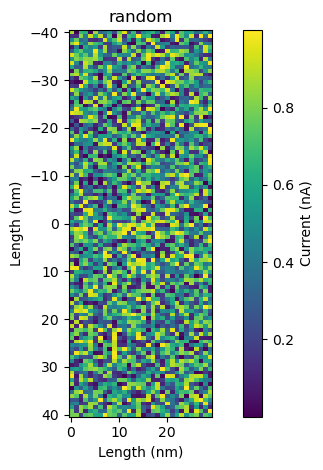

In [7]:
dataset.plot();

In [16]:
dataset.metadata

{'array': array([1, 2, 3])}

In [9]:
w = NSIDWriter(datasets)

In [10]:
w.write("test_nsid.hf5", overwrite=True)

/Users/borisslautin/miniconda3/envs/aespm/lib/python3.11/site-packages/pyNSID/io/hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


'test_nsid.hf5'

In [11]:
r = NSIDReader('test_nsid.hf5')
read_file = r.read()


In [12]:

read_file

{'Channel_000': sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(100, 100), dtype=float64, chunksize=(100, 100), chunktype=numpy.ndarray>
  data contains: Current (nA)
  and Dimensions: 
 x:  Length (nm) of size (100,)
 y:  Length (nm) of size (100,),
 'Channel_001': sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(30, 100), dtype=float64, chunksize=(30, 100), chunktype=numpy.ndarray>
  data contains: Current (nA)
  and Dimensions: 
 x:  Length (nm) of size (30,)
 y:  Length (nm) of size (100,)}

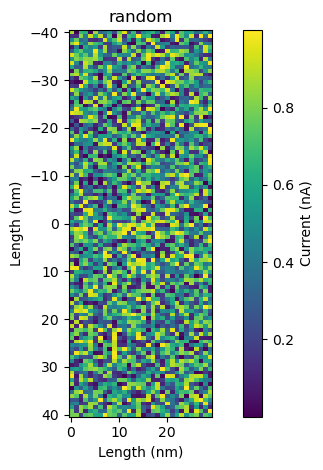

In [14]:
read_file['Channel_001'].plot();

In [15]:
read_file['Channel_000'].metadata

{}